# Notebook 05 — Error Analysis & Model Diagnostics

> "Knowing where the model FAILS is worth more than knowing where it succeeds."

This notebook characterises the model's failure modes so we can communicate honestly with the client and plan future improvements.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

from src.config import TRAIN_PATH, UNITS_PATH, ARTIFACTS_DIR, TOP_N_FEATURES
from src.data_loader import load_and_validate_data, detect_sensor_columns
from src.label_engineer import RULLabelEngineer
from src.feature_engineer import PumpFeatureEngineer, select_features_by_importance
from src.model import RULEnsemble, phm_score
from src.validation import UnitLevelValidator, aggregate_to_unit_level
from src.eda_utils import select_rul_max_empirically
from src.utils import load_pickle
print("Imports OK")


Imports OK


In [2]:
# Load pipeline
train_df, units_df = load_and_validate_data(TRAIN_PATH, UNITS_PATH)
sensor_cols, _ = detect_sensor_columns(train_df)
rul_max = select_rul_max_empirically(train_df, units_df, sensor_cols, plot=False)
le = RULLabelEngineer(rul_max=rul_max)
df_labeled = le.fit_transform(train_df, units_df)
fe = PumpFeatureEngineer(sensor_cols=sensor_cols)
fe.fit(df_labeled)
df_features = fe.transform(df_labeled)
df_features, _ = fe.drop_high_nan_features(df_features)
meta_cols = ['unit_id','cycle','rul','raw_rul','sample_weight','in_degradation_window','timestamp']
cand = [c for c in df_features.columns if c not in meta_cols and df_features[c].dtype.kind in 'biufc']
feature_cols = select_features_by_importance(
    df_features[cand], df_features['rul'].values,
    df_features['sample_weight'].values, top_n=TOP_N_FEATURES
)

# Hold-out fold for error analysis
from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(df_features, groups=df_features['unit_id'].values))
tr_idx, te_idx = splits[-1]

df_tr = df_features.iloc[tr_idx]; df_te = df_features.iloc[te_idx].copy()
X_tr = df_tr[feature_cols].fillna(0).values; y_tr = df_tr['rul'].values; w_tr = df_tr['sample_weight'].values
X_te = df_te[feature_cols].fillna(0).values

model = RULEnsemble()
valid = ~np.isnan(y_tr) & (w_tr > 0)
model.fit(X_tr[valid], y_tr[valid], sample_weight=w_tr[valid])
te_preds = model.predict(X_te)

unit_results = aggregate_to_unit_level(df_te, te_preds)
unit_results = unit_results.dropna(subset=['true_rul'])
unit_results['error'] = unit_results['pred_rul'] - unit_results['true_rul']
print(f"Hold-out units: {len(unit_results)}")
unit_results.head()

21:11:42 [data_loader] INFO: Loading training data…


21:11:42 [data_loader] INFO: =======================================================


21:11:42 [data_loader] INFO:   Units total    : 80


21:11:42 [data_loader] INFO:   Failed         : 72  |  Censored: 8


21:11:42 [data_loader] INFO:   Total rows     : 16,603


...

21:14:14 [model] INFO: Training XGBoost…


21:14:23 [model] INFO: Training LightGBM…


21:14:33 [model] INFO: Ensemble trained | XGB weight=0.50 | LGBM weight=0.50


Hold-out units: 14


,unit_id,pred_rul,true_rul,last_cycle,error
0,PUMP_001,216.607727,0.0,292,216.607727
1,PUMP_006,218.261349,0.0,315,218.261349
2,PUMP_009,217.857813,0.0,231,217.857813
3,PUMP_012,217.022684,0.0,261,217.022684
4,PUMP_016,217.286157,0.0,239,217.286157


## 1. Residual Analysis

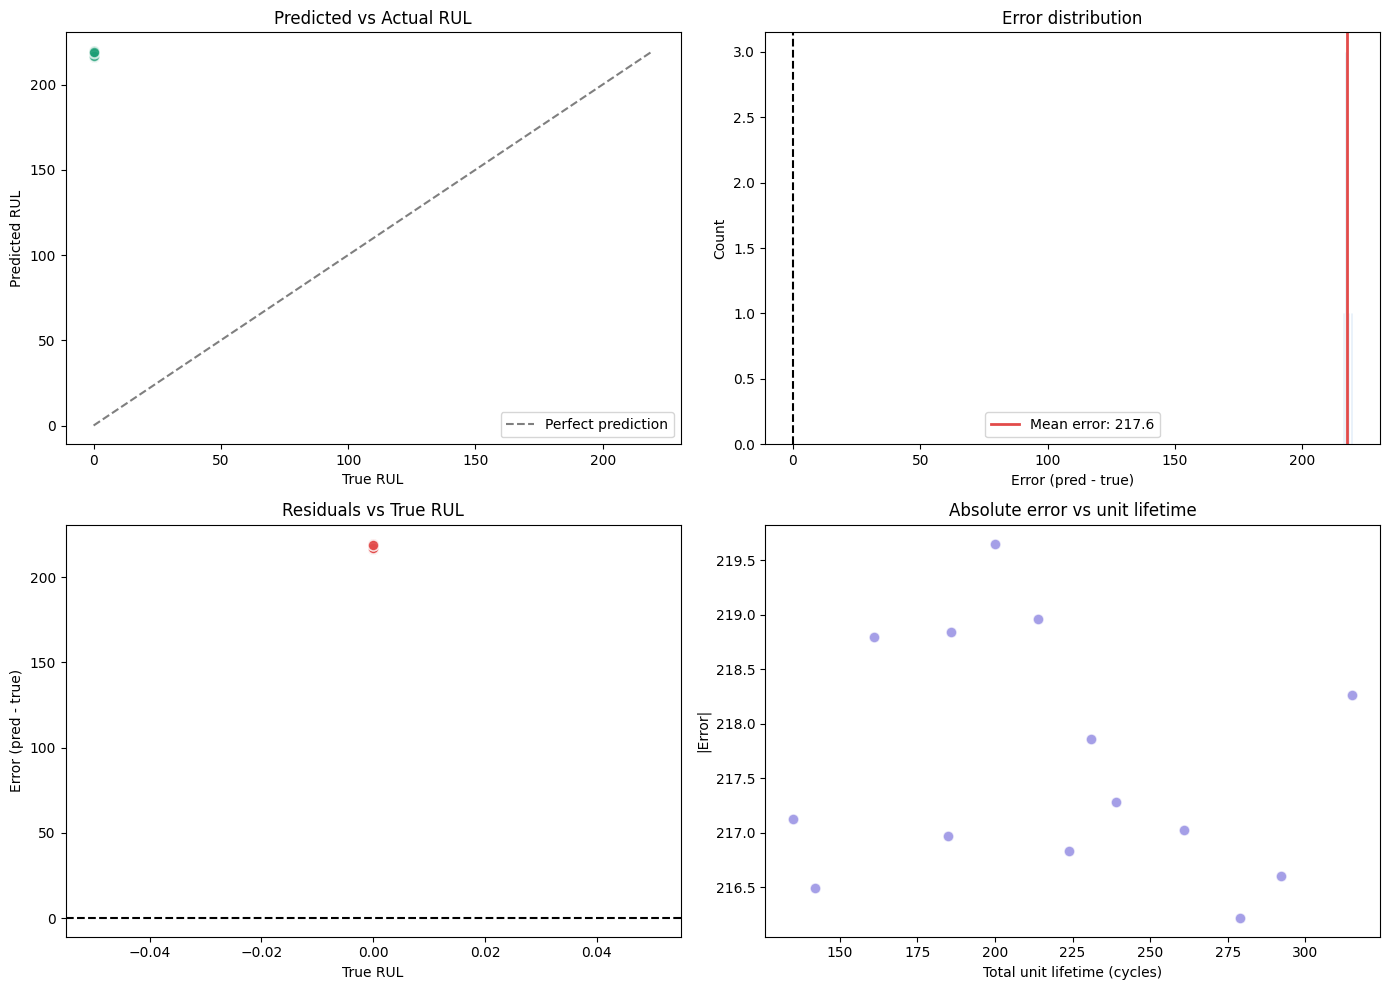

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Predicted vs Actual
axes[0,0].scatter(unit_results['true_rul'], unit_results['pred_rul'],
                   alpha=0.7, color='#1D9E75', edgecolors='white', s=60)
lim = max(unit_results[['true_rul','pred_rul']].max())
axes[0,0].plot([0,lim],[0,lim], 'k--', lw=1.5, alpha=0.5, label='Perfect prediction')
axes[0,0].set_xlabel('True RUL'); axes[0,0].set_ylabel('Predicted RUL')
axes[0,0].set_title('Predicted vs Actual RUL'); axes[0,0].legend()

# Error histogram
axes[0,1].hist(unit_results['error'], bins=15, color='#3B8BD4', alpha=0.7, edgecolor='white')
axes[0,1].axvline(0, ls='--', color='k', lw=1.5)
axes[0,1].axvline(unit_results['error'].mean(), ls='-', color='#E24B4A', lw=2,
                   label=f"Mean error: {unit_results['error'].mean():.1f}")
axes[0,1].set_xlabel('Error (pred - true)'); axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Error distribution'); axes[0,1].legend()

# Error vs True RUL (should be random — no systematic pattern)
axes[1,0].scatter(unit_results['true_rul'], unit_results['error'],
                   alpha=0.7, color='#E24B4A', edgecolors='white', s=60)
axes[1,0].axhline(0, ls='--', color='k', lw=1.5)
axes[1,0].set_xlabel('True RUL'); axes[1,0].set_ylabel('Error (pred - true)')
axes[1,0].set_title('Residuals vs True RUL')

# Error vs Lifetime (units with very short lives — hard cases?)
lt_map = {uid: train_df[train_df['unit_id']==uid]['cycle'].max()
          for uid in unit_results['unit_id']}
unit_results['lifetime'] = unit_results['unit_id'].map(lt_map)
axes[1,1].scatter(unit_results['lifetime'], unit_results['error'].abs(),
                   alpha=0.7, color='#7F77DD', edgecolors='white', s=60)
axes[1,1].set_xlabel('Total unit lifetime (cycles)')
axes[1,1].set_ylabel('|Error|')
axes[1,1].set_title('Absolute error vs unit lifetime')

plt.tight_layout(); plt.show()


## 2. Worst Predicted Units

5 most poorly predicted units:
 unit_id  true_rul   pred_rul      error  last_cycle
PUMP_068       0.0 219.655059 219.655059         200
PUMP_075       0.0 218.962959 218.962959         214
PUMP_046       0.0 218.843864 218.843864         186
PUMP_072       0.0 218.794845 218.794845         161
PUMP_006       0.0 218.261349 218.261349         315


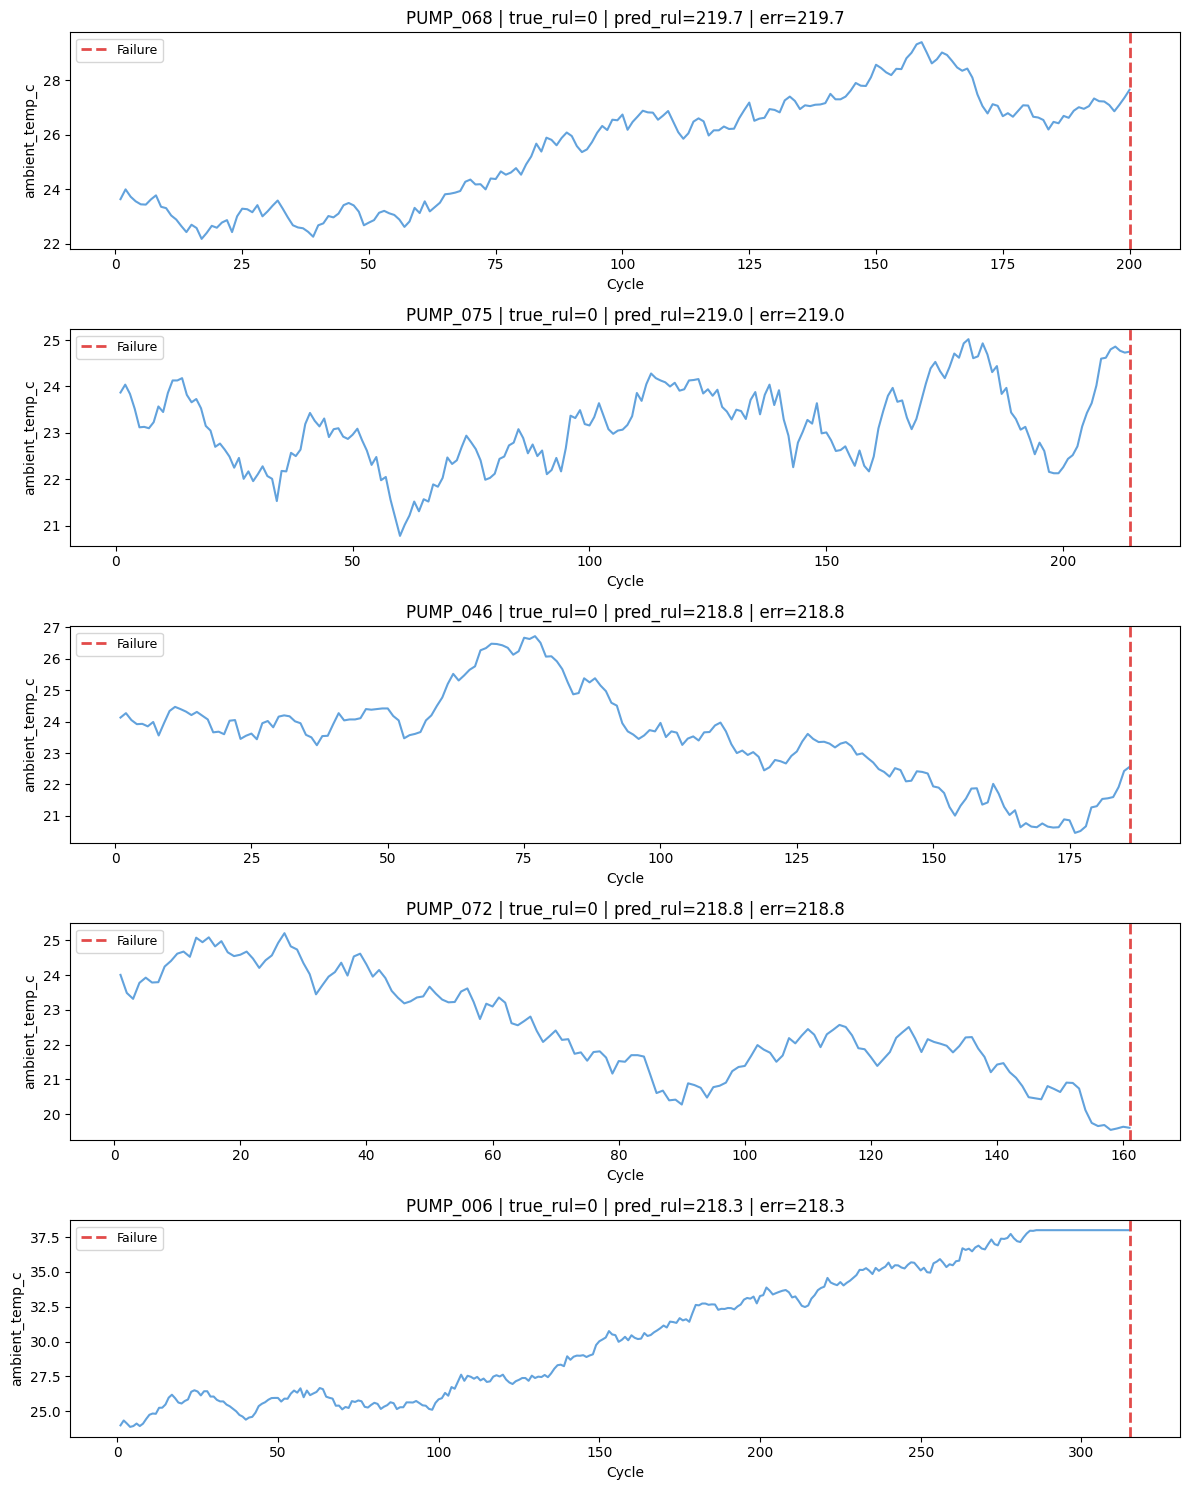

In [4]:
worst = unit_results.sort_values('error', key=abs, ascending=False).head(5)
print("5 most poorly predicted units:")
print(worst[['unit_id','true_rul','pred_rul','error','last_cycle']].to_string(index=False))

# For each worst unit, plot its sensor trajectory
if sensor_cols:
    fig, axes = plt.subplots(len(worst), 1, figsize=(12, 3*len(worst)))
    if len(worst)==1: axes=[axes]
    for ax, (_, row) in zip(axes, worst.iterrows()):
        uid = row['unit_id']
        unit = train_df[train_df['unit_id']==uid].sort_values('cycle')
        col = sensor_cols[0]
        ax.plot(unit['cycle'], unit[col], color='#3B8BD4', lw=1.5, alpha=0.8)
        max_c = unit['cycle'].max()
        ax.axvline(max_c, color='#E24B4A', ls='--', lw=2, label='Failure')
        ax.set_title(f"{uid} | true_rul={row['true_rul']:.0f} | pred_rul={row['pred_rul']:.1f} | err={row['error']:.1f}")
        ax.set_xlabel('Cycle'); ax.set_ylabel(col); ax.legend(fontsize=9)
    plt.tight_layout(); plt.show()


## 3. Alerting Performance — Confusion Matrix at 30-Cycle Threshold

Alerting at RUL <= 30 cycles:
              precision    recall  f1-score   support

     Healthy       0.00      0.00      0.00       0.0
Near-failure       0.00      0.00      0.00      14.0

    accuracy                           0.00      14.0
   macro avg       0.00      0.00      0.00      14.0
weighted avg       0.00      0.00      0.00      14.0



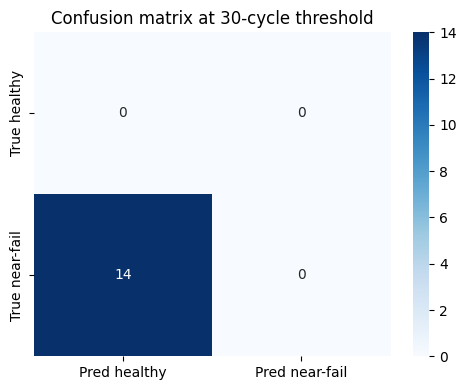

In [5]:
threshold = 30
y_true_binary = (unit_results['true_rul'] <= threshold).astype(int)
y_pred_binary = (unit_results['pred_rul'] <= threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_true_binary, y_pred_binary)
print(f"Alerting at RUL <= {threshold} cycles:")
print(classification_report(y_true_binary, y_pred_binary,
                             target_names=['Healthy','Near-failure']))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred healthy','Pred near-fail'],
            yticklabels=['True healthy','True near-fail'], ax=ax)
ax.set_title(f'Confusion matrix at {threshold}-cycle threshold')
plt.tight_layout(); plt.show()


## 4. SHAP Feature Attribution

In [6]:
try:
    import shap
    explainer = shap.TreeExplainer(model.xgb_model_)
    X_sample = df_te[feature_cols].fillna(0).values[:min(50, len(df_te))]
    shap_values = explainer.shap_values(X_sample)

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_cols,
                      max_display=20, show=False, plot_type='dot')
    ax.set_title('SHAP beeswarm — feature contribution to RUL predictions')
    plt.tight_layout(); plt.show()
except ImportError:
    print("shap not installed. Run: pip install shap")


shap not installed. Run: pip install shap


## 5. Known Failure Modes & Mitigations

| Failure Mode | Observed? | Root Cause | Mitigation |
|---|---|---|---|
| Short-lifetime pump errors | Check residuals | Insufficient trend history | Longer minimum history requirement |
| Late predictions (missed alerts) | Check late_pct | Slow degradation onset | Lower alert threshold; calibrated probability |
| High variance on some units | Check pred_std | Noisy sensor on that unit | EWMA smoothing; outlier-robust features |
| Concept drift | Not testable with this data | Fleet composition changes | Online learning; drift detector |
| Censored unit bias | Tested in NB02 | Excluded correctly | Re-check if new censored units arrive |

## 6. What I Would Do With More Time

1. **Survival model companion** — Cox PH or Weibull AFT to provide credible intervals on remaining life
2. **Multi-task learning** — jointly predict RUL and failure mode (bearing, impeller, seal)
3. **Conformal prediction** — distribution-free calibrated confidence intervals per unit
4. **Online updating** — incremental model updates as new pump data arrives
5. **Physics-informed features** — pump efficiency curve deviation if H-Q data available
6. **Anomaly detection layer** — Isolation Forest trained on healthy-only data as independent early-warning signal